In [1]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import seaborn as sns
from sklearn.metrics import roc_auc_score
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree
from sklearn.metrics import roc_curve,auc
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, accuracy_score

In [3]:
# Load the Telco Customer Churn dataset
data = pd.read_csv('Telco-Customer-Churn.csv')

# Quick look at the data
print(data.head())
print(data.info())

   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

In [4]:
data = data.drop('customerID', axis=1)

# Convert TotalCharges to numeric, coerce errors to NaN
data['TotalCharges'] = pd.to_numeric(data['TotalCharges'], errors='coerce')

# Fill missing TotalCharges with median
data['TotalCharges']=data['TotalCharges'].fillna(data['TotalCharges'].median())

# Encode target variable 'Churn'
data['Churn'] = data['Churn'].map({'Yes':1, 'No':0})

cat_cols = data.select_dtypes(include='object').columns
le = LabelEncoder()
for col in cat_cols:
    data[col] = le.fit_transform(data[col])

num_cols = ['tenure','MonthlyCharges','TotalCharges']
scaler = StandardScaler()
data[num_cols] = scaler.fit_transform(data[num_cols])

In [5]:
X = data.drop('Churn', axis=1)
y = data['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print("x_train.shape:" ,X_train.shape)
print("y_train.shape:" ,y_train.shape)
print("x_test.shape:" ,X_test.shape)
print("y_test.shape:" ,y_test.shape)

x_train.shape: (5634, 19)
y_train.shape: (5634,)
x_test.shape: (1409, 19)
y_test.shape: (1409,)


In [6]:
param_grid = {
    'criterion': ['gini', 'entropy'],
    'splitter': ['best', 'random'],

    #pre-pruning
    'max_depth': [None, 5, 10, 15, 20, 30],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 8],

    #feature selection per split
    'max_features': [None, 'sqrt', 'log2'],

    #post-pruning
    'ccp_alpha': [0.0, 0.0005, 0.001,0.0015, 0.01]
}
# Model
dt = DecisionTreeClassifier(random_state=42)

# Grid Search
grid_search = GridSearchCV(
    estimator=dt,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

# Fit
grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best Accuracy:", grid_search.best_score_)

Best Parameters: {'ccp_alpha': 0.001, 'criterion': 'entropy', 'max_depth': 10, 'max_features': None, 'min_samples_leaf': 4, 'min_samples_split': 20, 'splitter': 'random'}
Best Accuracy: 0.7960570590117273


In [7]:
clf = DecisionTreeClassifier(
    random_state=0,
    criterion='entropy',
    ccp_alpha=0.001,
    max_depth=10,
    min_samples_leaf=4,
    min_samples_split=20,
    splitter='random'
)
clf.fit(X_train, y_train)

y_pred_proba = clf.predict_proba(X_test)[:, 1]

auccuracy = roc_auc_score(y_test, y_pred_proba)
print("ROC-AUC Score:", auccuracy)





ROC-AUC Score: 0.8250045209124492


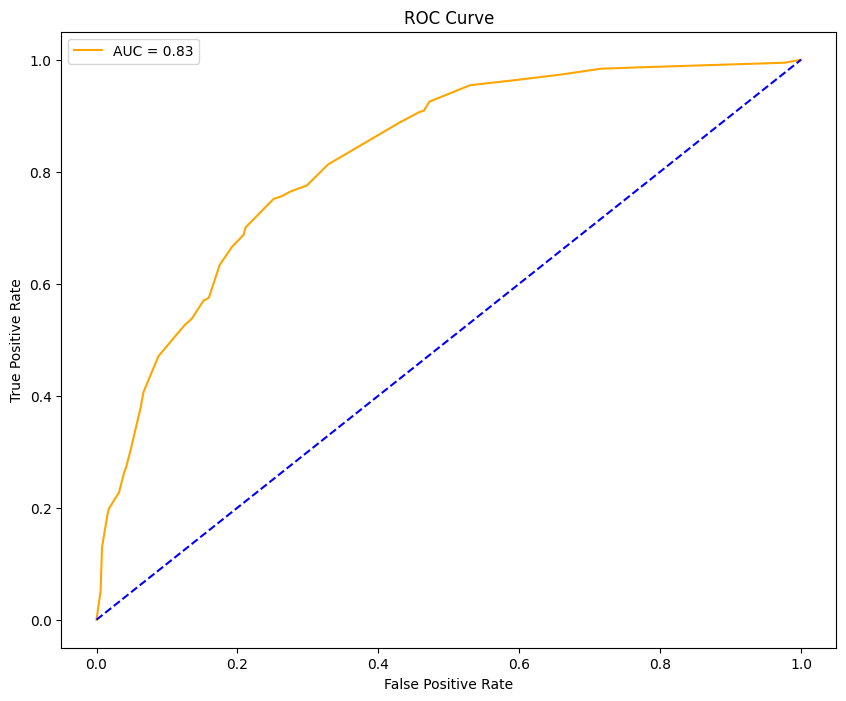

In [8]:
fpr_dt, tpr_dt, thresholds_dt = roc_curve(y_test, y_pred_proba)
auc_dt = roc_auc_score(y_test, y_pred_proba)

def plot_roc_curve(fpr, tpr, auc_score):
    plt.figure(figsize=(10,8))
    plt.plot(fpr, tpr, color='orange', label=f'AUC = {auc_score:.2f}')
    plt.plot([0,1],[0,1],'--', color='blue')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend()
    plt.show()

plot_roc_curve(fpr_dt, tpr_dt, auc_dt)

[Text(0.6654829545454546, 0.95, 'x[14] <= 0.221\nentropy = 0.835\nsamples = 5634\nvalue = [4139, 1495]'),
 Text(0.4446022727272727, 0.85, 'x[11] <= 0.374\nentropy = 0.985\nsamples = 3102\nvalue = [1776, 1326]'),
 Text(0.5550426136363636, 0.8999999999999999, 'True  '),
 Text(0.2528409090909091, 0.75, 'x[7] <= 0.196\nentropy = 1.0\nsamples = 2144\nvalue = [1062, 1082]'),
 Text(0.11363636363636363, 0.65, 'x[17] <= -0.51\nentropy = 0.942\nsamples = 706\nvalue = [452.0, 254.0]'),
 Text(0.06818181818181818, 0.55, 'x[18] <= -0.583\nentropy = 0.988\nsamples = 374\nvalue = [211, 163]'),
 Text(0.045454545454545456, 0.45, 'x[4] <= -1.117\nentropy = 0.997\nsamples = 319\nvalue = [169, 150]'),
 Text(0.022727272727272728, 0.35, 'entropy = 0.983\nsamples = 182\nvalue = [77.0, 105.0]'),
 Text(0.06818181818181818, 0.35, 'x[12] <= 1.015\nentropy = 0.913\nsamples = 137\nvalue = [92, 45]'),
 Text(0.045454545454545456, 0.25, 'entropy = 0.86\nsamples = 120\nvalue = [86, 34]'),
 Text(0.09090909090909091, 0.2

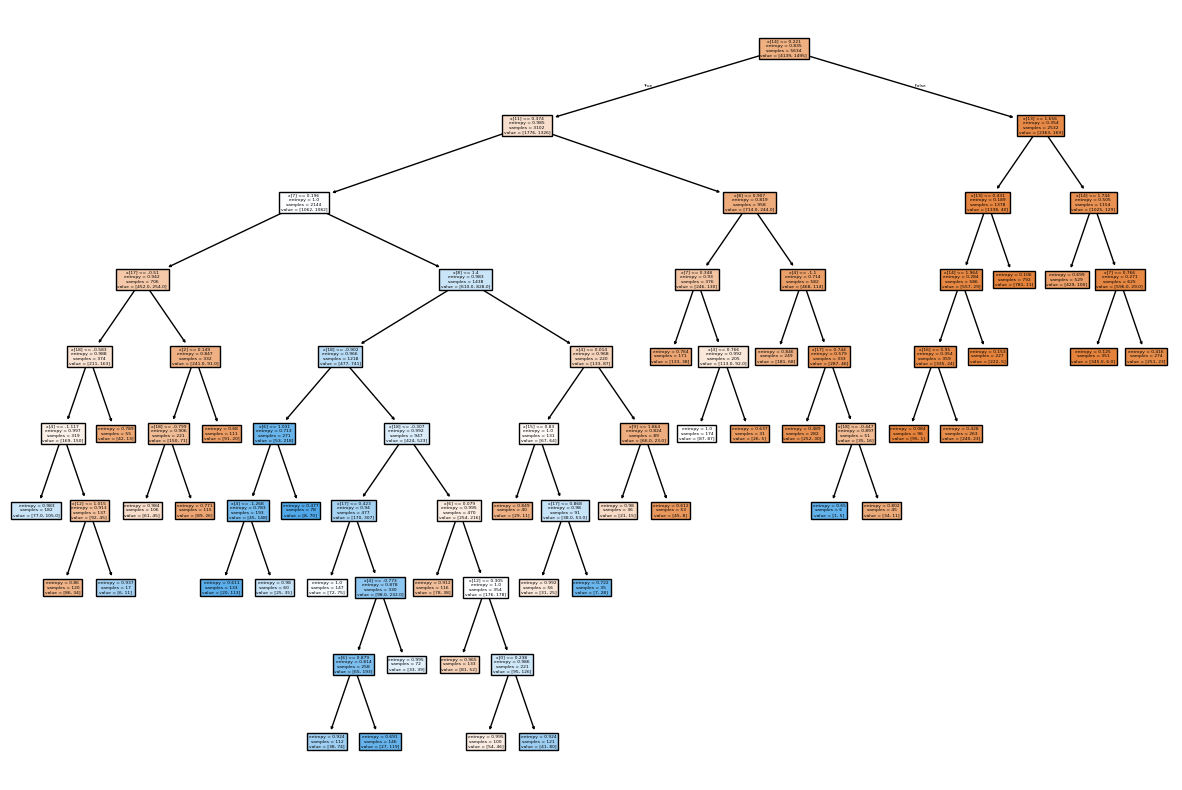

In [9]:
plt.figure(figsize=(15,10))
tree.plot_tree(clf,filled=True)